In [1]:
%config InlineBackend.figure_formats = ['svg']
import math  # noqa
import random  # noqa
import itertools  # noqa
import functools  # noqa
import collections  # noqa
import tqdm  # noqa
import numpy as np  # noqa
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa
import quimb as qu  # noqa
import xyzpy as xyz  # noqa
import autoray as ar  # noqa
import cotengra as ctg  # noqa
import quimb.tensor as qtn  # noqa

In [2]:
tn = qtn.PEPS.rand(4, 5, 4)
# tn = qtn.MPS_rand_state(20, 7)

# tn = qtn.TN2D_rand(32, 32, D=2)


inputs, output, size_dict = tn.get_inputs_output_size_dict()
symbol_map = tn.get_symbol_map()

rng = ctg.utils.get_rng(42)

M = 200

sliced_inds = output

configs = [{ix: rng.choice([0, 1]) for ix in output} for _ in range(M)]

tree = ctg.array_contract_tree(
    inputs,
    output,
    size_dict,
)

In [11]:
# inputs, output, shapes, size_dict = ctg.utils.randreg_equation(100, 4, seed=42)
inputs, output, shapes, size_dict = ctg.utils.lattice_equation(
    [28, 28], d_max=2
)

opt = ctg.HyperOptimizer(
    simulated_annealing_opts=dict(target_size=2**24),
    max_repeats=8,
    progbar=True,
)

In [12]:
tree = opt.search(inputs, output, size_dict)

F=14.05 C=14.72 S=24 P=25.02 $=8192: 100%|██████████| 16/16 [01:56<00:00,  7.31s/it]    


In [13]:
sliced_inds = tree.sliced_inds
configs = [
    dict(zip(sliced_inds, x))
    for x in itertools.product(*[range(size_dict[i]) for i in sliced_inds])
]
len(configs)

8192

In [14]:
tree.contraction_cost() / tree.unslice_all().contraction_cost()

1.573196922320367

In [15]:
tree.max_size(log=2)

24.0

In [3]:
from cotengra.core import (
    ContractionTree,
    get_score_fn,
)
from cotengra.scoring import Objective


class MultiObjective(Objective):
    __slots__ = ("num_configs",)

    def __init__(self, num_configs):
        self.num_configs = num_configs

    def compute_mult(self, dims):
        raise NotImplementedError

    def estimate_node_mult(self, tree, node):
        return self.compute_mult(
            [tree.size_dict[ix] for ix in tree.get_node_var_inds(node)]
        )

    def estimate_node_cache_mult(self, tree, node, sliced_ind_ordering):
        node_var_inds = tree.get_node_var_inds(node)

        # indices which are the first 'k' in the sliced ordering
        non_heavy_inds = [
            ix
            for ix in tree.get_node_var_inds(node)
            if ix not in sliced_ind_ordering[: len(node_var_inds)]
        ]

        # each of these cycles 'out of sync' and thus must be kept
        return self.compute_mult([tree.size_dict[ix] for ix in non_heavy_inds])


class MultiObjectiveDense(MultiObjective):
    """Number of intermediate configurations is expected to scale as if all
    configurations are present.
    """

    __slots__ = ("num_configs",)

    def compute_mult(self, dims):
        return math.prod(dims)


def expected_coupons(num_sub, num_total):
    """If we draw a random 'coupon` which can take `num_sub` different values
    `num_total` times, how many unique coupons will we expect?
    """
    # return min(num_sub, num_total)
    return num_sub * (1 - (1 - 1 / num_sub) ** num_total)


class MultiObjectiveUniform(MultiObjective):
    """Number of intermediate configurations is expected to scale as if all
    configurations are randomly draw from a uniform distribution.
    """

    __slots__ = ("num_configs",)

    def compute_mult(self, dims):
        return expected_coupons(math.prod(dims), self.num_configs)


class MultiObjectiveLinear(MultiObjective):
    """Number of intermediate configurations is expected to scale linearly with
    respect to number of variable indices (e.g. VMC like 'locally connected'
    configurations).
    """

    __slots__ = ("num_configs", "coeff")

    def __init__(self, num_configs, coeff=1):
        self.coeff = coeff
        super().__init__(num_configs=num_configs)

    def compute_mult(self, dims):
        return min(self.coeff * len(dims), self.num_configs)

In [18]:
M = len(configs)
# objective = MultiObjectiveUniform(num_configs=M)
# objective = MultiObjectiveDense(num_configs=M)
objective = MultiObjectiveLinear(num_configs=M, coeff=M / len(sliced_inds))

mtree = ctg.ContractionTreeMulti.from_path(
    inputs,
    output,
    size_dict,
    sliced_inds=sliced_inds,
    objective=objective,
    path=tree.get_path(),
)
mtree.reorder_contractions_for_peak_est()
mtree.reorder_sliced_inds()

In [19]:
mtree.multiplicity

1

In [20]:
mtree.contract_stats()

{'flops': 5273600.0, 'write': 6913, 'size': 1024}

In [21]:
math.log10(339021824)

8.5302276561314

In [22]:
math.log10(
    sum(
        ContractionTree.get_flops(mtree, node)
        for node, _, _ in mtree.descend()
    )
)

4.920123326290724

In [23]:
math.log10(sum(mtree.get_flops(node) for node, _, _ in mtree.descend()))

6.722107185681003

In [24]:
mtree.contraction_cost(log=10)

6.722107185681002

In [25]:
stats = mtree.exact_multi_stats(configs)
stats

{'flops': 6203392, 'write': 248008, 'size': 1024, 'peak': 111360}

In [12]:
math.log10(stats["flops"])

6.792629225636649

In [16]:
mtree.peak_size(log=2)

16.98299357469431

In [17]:
math.log2(stats["peak"])

16.764871590736092

In [19]:
from cotengra.pathfinders.path_simulated_annealing import (
    _describe_tree,
    _slice_tree_basic,
    _slice_tree_drift,
    _slice_tree_reslice,
    get_rng,
    linspace_generator,
)


def compute_contracted_info(
    legsa,
    legsb,
    appearances,
    size_dict,
    var_inds_a,
    var_inds_b,
):
    """Compute the contracted legs, cost and size of a pair of legs.

    Parameters
    ----------
    legsa : dict[str, int]
        The legs of the first tensor.
    legsb : dict[str, int]
        The legs of the second tensor.
    appearances : dict[str, int]
        The total number of appearances of each index in the contraction.
    size_dict : dict[str, int]
        The size of each index.

    Returns
    -------
    legsab : dict[str, int]
        The contracted legs.
    cost : int
        The cost of the contraction.
    size : int
        The size of the resulting tensor.
    """
    legsab = {}
    cost = 1
    size = 1

    # handle all left indices
    for ix, ix_count in legsa.items():
        d = size_dict[ix]
        # all involved indices contribute to cost
        cost *= d
        if ix in legsb:
            ix_count += legsb[ix]
        if ix_count < appearances[ix]:
            # index appears on output
            legsab[ix] = ix_count
            # and so contributes to size
            size *= d

    # now handle right indices that we haven't seen yet
    for ix, ix_count in legsb.items():
        if ix not in legsa:
            d = size_dict[ix]
            cost *= d
            if ix_count < appearances[ix]:
                legsab[ix] = ix_count
                size *= d

    return legsab, cost, size, var_inds_a | var_inds_b


def simulated_anneal_tree(
    tree,
    tfinal=0.05,
    tstart=2,
    tsteps=50,
    numiter=50,
    minimize=None,
    target_size=None,
    target_size_initial=None,
    slice_mode="basic",
    seed=None,
    progbar=False,
    inplace=False,
):
    """Perform a simulated annealing optimization of this contraction
    tree, based on "Multi-Tensor Contraction for XEB Verification of
    Quantum Circuits" by Gleb Kalachev, Pavel Panteleev, Man-Hong Yung
    (arXiv:2108.05665), and the "treesa" implementation in
    OMEinsumContractionOrders.jl by Jin-Guo Liu and Pan Zhang.

    Parameters
    ----------
    tfinal : float, optional
        The final temperature.
    tstart : float, optional
        The starting temperature.
    tsteps : int, optional
        The number of temperature steps.
    numiter : int, optional
        The number of sweeps at each temperature step.
    minimize : {'flops', 'combo', 'write', 'size', ...}, optional
        The objective function to minimize.
    target_size : int, optional
        The target size to slice the contraction to. A schedule is used to
        reach this only at the final temperature step.
    target_size_initial : int, optional
        The initial target size to use in the slicing schedule. If None, then
        the current size is used.
    slice_mode : {'basic', 'reslice', 'drift'}, optional
        The mode for slicing the contraction tree within each annealing
        iteration. 'basic' always unslices a random index and then slices to
        the target size. 'reslice' unslices all indices and then slices to the
        target size. 'drift' unslices a random index with probability 1/4 and
        slices to the target size with probability 3/4. It is therefore not
        guaranteed to reach the target size, but may be more explorative for
        long annealing schedules.
    seed : int, optional
        A random seed.
    progbar : bool, optional
        Whether to show live progress.
    inplace : bool, optional
        Whether to perform the optimization inplace.

    Returns
    -------
    ContractionTree
    """

    tree = tree if inplace else tree.copy()
    # ensure stats tracking is on
    tree.contract_stats()

    if minimize is None:
        minimize = tree.get_default_objective()
    scorer = get_score_fn(minimize)
    rng = get_rng(seed)

    # create a schedule for annealing temperatures
    temps = linspace_generator(tstart, tfinal, tsteps, log=True)

    if target_size is not None:
        # create a schedule for slicing target sizes
        if target_size_initial is None:
            # start with the current size
            current_size = max(tree.contraction_width(log=None), target_size)
        else:
            current_size = max(target_size_initial, target_size)

        target_sizes = linspace_generator(
            current_size,
            target_size,
            tsteps,
            log=True,
        )
        _slice_tree = {
            "basic": _slice_tree_basic,
            "reslice": _slice_tree_reslice,
            "drift": _slice_tree_drift,
        }[slice_mode]
    else:
        target_sizes = itertools.repeat(None)

        def _slice_tree(tree, current_target_size, rng):
            pass

    if progbar:
        import tqdm

        pbar = tqdm.tqdm(total=tsteps)
        pbar.set_description(_describe_tree(tree))

    for temp in temps:
        # handle slicing
        _slice_tree(tree, next(target_sizes), rng)

        for _ in range(numiter):
            candidates = [tree.root]

            while candidates:
                p = candidates.pop(0)
                l, r = tree.children[p]

                # check which local moves are possible
                if len(l) == 1:
                    if len(r) == 1:
                        # both are leaves
                        continue
                    else:
                        # left is leaf
                        rule = rng.randint(2, 3)
                elif len(r) == 1:
                    # right is leaf
                    rule = rng.randint(0, 1)
                else:
                    # neither are leaves
                    rule = rng.randint(0, 3)

                if rule < 2:
                    # ((AB)C)
                    x, c = l, r
                    a, b = tree.children[x]
                    if rule == 0:
                        # -> ((AC)B)
                        new_order = [a, c, b]
                    else:
                        # -> (A(BC))
                        new_order = [b, c, a]
                else:
                    # (A(BC))
                    a, x = l, r
                    b, c = tree.children[x]
                    if rule == 2:
                        # -> (B(AC))
                        new_order = [a, c, b]
                    else:
                        # -> (C(AB))
                        new_order = [a, b, c]

                current_score = math.log2(
                    tree.get_flops(p) + tree.get_flops(x)
                )

                # current_score = scorer.score_local(
                #     flops=[tree.get_flops(p), tree.get_flops(x)],
                #     size=[tree.get_size(p), tree.get_size(x)],
                # )

                # legs0 = tree.get_legs(new_order[0])
                # legs1 = tree.get_legs(new_order[1])
                # if any(ix0 in legs1 for ix0 in legs0):

                # compute new intermediate
                new_legs0, new_cost0, new_size0, new_var_inds0 = (
                    compute_contracted_info(
                        tree.get_legs(new_order[0]),
                        tree.get_legs(new_order[1]),
                        tree.appearances,
                        tree.size_dict,
                        tree.get_node_var_inds(new_order[0]),
                        tree.get_node_var_inds(new_order[1]),
                    )
                )

                new_mult_cost0 = new_cost0 * scorer.estimate_mult(
                    [tree.size_dict[ix] for ix in new_var_inds0]
                )

                # compute new parent costs
                new_legs1, new_cost1, new_size1, new_var_inds1 = (
                    compute_contracted_info(
                        new_legs0,
                        tree.get_legs(new_order[2]),
                        tree.appearances,
                        tree.size_dict,
                        new_var_inds0,
                        tree.get_node_var_inds(new_order[2]),
                    )
                )

                new_mult_cost1 = new_cost1 * scorer.estimate_mult(
                    [tree.size_dict[ix] for ix in new_var_inds1]
                )

                proposed_score = math.log2(new_mult_cost0 + new_mult_cost1)

                # proposed_score = scorer.score_local(
                #     flops=[new_cost0, new_cost1],
                #     size=[new_size0, new_size1],
                # )

                dE = proposed_score - current_score
                accept = (dE <= 0) or (math.log(rng.random()) < -dE / temp)

                if accept:
                    tree._remove_node(p)
                    tree._remove_node(x)

                    tree.contract_nodes_pair(
                        tree.contract_nodes_pair(
                            new_order[0],
                            new_order[1],
                            legs=new_legs0,
                            cost=new_cost0,
                            size=new_size0,
                        ),
                        new_order[2],
                        legs=new_legs1,
                        cost=new_cost1,
                        size=new_size1,
                    )

                    if progbar:
                        pbar.set_description(
                            f"T: {temp:.2e} " + _describe_tree(tree),
                            refresh=False,
                        )

                # check which children to recurse into
                l, r = tree.children[p]
                if len(l) > 2:
                    candidates.append(l)
                if len(r) > 2:
                    candidates.append(r)

        if progbar:
            pbar.update()

    return tree

In [32]:
simulated_anneal_tree(mtree, inplace=True, progbar=True)

T: 5.00e-02 F=6.708 C=6.744 S=10 P=11.74 $=1: 100%|██████████| 50/50 [00:00<00:00, 55.26it/s]


<ContractionTreeMulti(N=20)>

In [33]:
stats = mtree.exact_multi_stats(configs)
stats

{'flops': 7598080, 'write': 475336, 'size': 1024, 'peak': 61953}

In [34]:
math.log10(stats["flops"])

6.880703861918839

In [7]:
mtree.get_default_objective()

MultiObjectiveLinear(num_configs=200, coeff=2.0)

In [10]:
mtree.estimate_multi_total_flops() / (ContractionTree.total_flops(mtree) * M)

0.3460989920591954

In [12]:
configs.sort(key=lambda c: tuple(c[ix] for ix in sliced_ind_ordering))

In [126]:
stats["flops"] / tree.total_flops()

3.920360304532837e-21

In [127]:
stats["flops"] / tree.unslice_all().total_flops()

3.920360304532837e-21

In [128]:
tree.unslice_all().peak_size(log=2)

104.0

In [129]:
ContractionTree.max_size(mtree, log=2)

28.0

In [130]:
math.log2(stats["peak"])

29.067312900309663

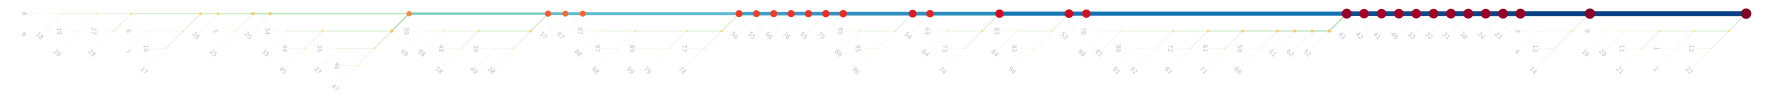

(<Figure size 3162.28x3162.28 with 1 Axes>, <Axes: >)

In [120]:
tree.plot_circuit()